In [6]:
!pip install deepface retina-face tf-keras scikit-learn matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.1 MB/s eta 0:00:00


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_pairs
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from deepface import DeepFace
from tqdm import tqdm

SIMILARITY_THRESHOLD = 0.6
MAX_AGE_GAP = 5

def cosine_similarity(vector_a, vector_b):
    norm_a = np.linalg.norm(vector_a)
    norm_b = np.linalg.norm(vector_b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(vector_a, vector_b) / (norm_a * norm_b))

def get_verdict(score):
    return "verified" if score >= SIMILARITY_THRESHOLD else "suspicious"

def normalize_image(img):
    img = img - img.min()
    img = img / img.max()
    return (img * 255).astype("uint8")

print("imports ok")
print(f"similarity threshold: {SIMILARITY_THRESHOLD}")

26-04-21 18:15:19 - Directory /root/.deepface has been created
26-04-21 18:15:19 - Directory /root/.deepface/weights has been created
imports ok
similarity threshold: 0.6


total pairs: 1000
matched pairs: 500
non-matched pairs: 500


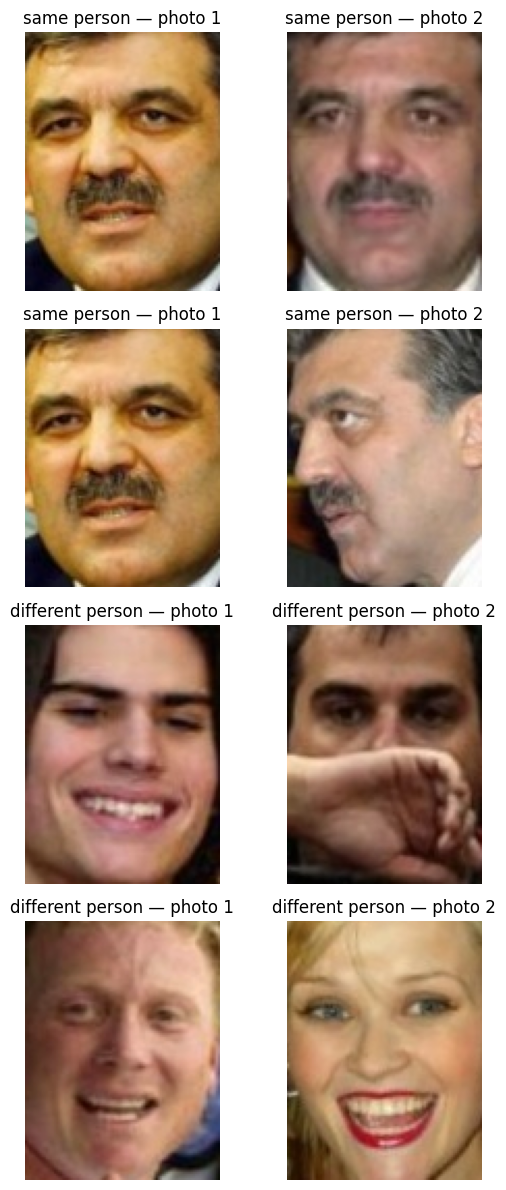

In [8]:
lfw_pairs = fetch_lfw_pairs(subset="test", color=True, resize=1.0)

print(f"total pairs: {len(lfw_pairs.pairs)}")
print(f"matched pairs: {sum(lfw_pairs.target)}")
print(f"non-matched pairs: {len(lfw_pairs.target) - sum(lfw_pairs.target)}")

fig, axes = plt.subplots(4, 2, figsize=(6, 12))
matched_idx = np.where(lfw_pairs.target == 1)[0]
nonmatched_idx = np.where(lfw_pairs.target == 0)[0]

for i, idx in enumerate(matched_idx[:2]):
    axes[i][0].imshow(normalize_image(lfw_pairs.pairs[idx][0]))
    axes[i][0].set_title("same person — photo 1")
    axes[i][0].axis("off")
    axes[i][1].imshow(normalize_image(lfw_pairs.pairs[idx][1]))
    axes[i][1].set_title("same person — photo 2")
    axes[i][1].axis("off")

for i, idx in enumerate(nonmatched_idx[:2]):
    axes[i+2][0].imshow(normalize_image(lfw_pairs.pairs[idx][0]))
    axes[i+2][0].set_title("different person — photo 1")
    axes[i+2][0].axis("off")
    axes[i+2][1].imshow(normalize_image(lfw_pairs.pairs[idx][1]))
    axes[i+2][1].set_title("different person — photo 2")
    axes[i+2][1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
from tqdm import tqdm

scores = []
labels = []

print("running arcface on 1000 pairs...")

for i in tqdm(range(len(lfw_pairs.pairs))):
    try:
        img1 = normalize_image(lfw_pairs.pairs[i][0])
        img2 = normalize_image(lfw_pairs.pairs[i][1])

        emb1 = DeepFace.represent(
            img_path=img1,
            model_name="ArcFace",
            detector_backend="retinaface",
            enforce_detection=False
        )[0]["embedding"]

        emb2 = DeepFace.represent(
            img_path=img2,
            model_name="ArcFace",
            detector_backend="retinaface",
            enforce_detection=False
        )[0]["embedding"]

        score = cosine_similarity(np.array(emb1), np.array(emb2))
        scores.append(score)
        labels.append(lfw_pairs.target[i])

    except Exception as e:
        print(f"skipped pair {i}: {e}")
        continue

print(f"evaluated {len(scores)} pairs successfully")
print(f"failed: {len(lfw_pairs.pairs) - len(scores)}")

running arcface on 1000 pairs...


  0%|          | 0/1000 [00:00<?, ?it/s]

26-04-21 18:16:16 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5

  0%|          | 0.00/137M [00:00<?, ?B/s]
 18%|█▊        | 24.6M/137M [00:00<00:00, 245MB/s]
 39%|███▉      | 53.5M/137M [00:00<00:00, 269MB/s]
 60%|██████    | 82.3M/137M [00:00<00:00, 275MB/s]
100%|██████████| 137M/137M [00:00<00:00, 275MB/s]


26-04-21 18:16:20 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5

  0%|          | 0.00/119M [00:00<?, ?B/s]
 15%|█▍        | 17.3M/119M [00:00<00:00, 171MB/s]
 43%|████▎     | 51.4M/119M [00:00<00:00, 269MB/s]
 72%|███████▏  | 84.9M/119M [00:00<00:00, 299MB/s]
100%|██████████| 119M/119M [00:00<00:00, 286MB/s]
100%|██████████| 1000/1000 [08:33<00:00,  1.95it/s]

evaluated 1000 pairs successfully
failed: 0


accuracy: 0.7250
true positives (correctly verified): 225
true negatives (correctly suspicious): 500
false positives (wrong person let through): 0
false negatives (real person blocked): 275


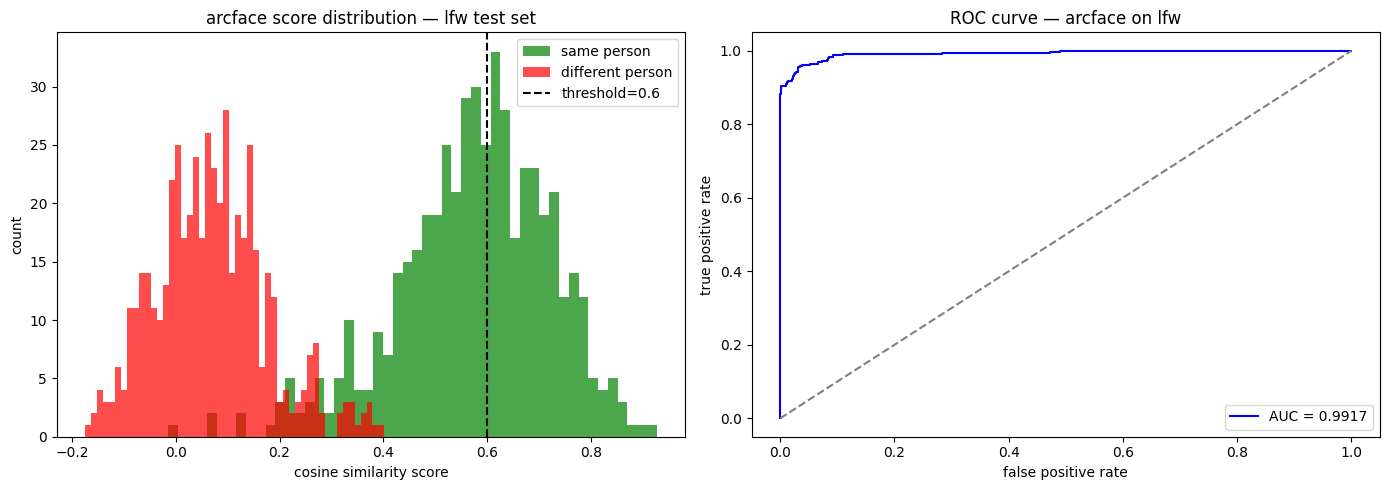

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

scores = np.array(scores)
labels = np.array(labels)

#apply threshold to get predictions
predictions = (scores >= SIMILARITY_THRESHOLD).astype(int)

#accuracy
accuracy = accuracy_score(labels, predictions)
cm = confusion_matrix(labels, predictions)
tn, fp, fn, tp = cm.ravel()

print(f"accuracy: {accuracy:.4f}")
print(f"true positives (correctly verified): {tp}")
print(f"true negatives (correctly suspicious): {tn}")
print(f"false positives (wrong person let through): {fp}")
print(f"false negatives (real person blocked): {fn}")

#plot score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#distribution plot
matched_scores = scores[labels == 1]
nonmatched_scores = scores[labels == 0]

axes[0].hist(matched_scores, bins=50, alpha=0.7, color="green", label="same person")
axes[0].hist(nonmatched_scores, bins=50, alpha=0.7, color="red", label="different person")
axes[0].axvline(x=SIMILARITY_THRESHOLD, color="black", linestyle="--", label=f"threshold={SIMILARITY_THRESHOLD}")
axes[0].set_xlabel("cosine similarity score")
axes[0].set_ylabel("count")
axes[0].set_title("arcface score distribution — lfw test set")
axes[0].legend()

#roc curve
fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve — arcface on lfw")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
#verify results at optimal threshold 0.28
optimal_threshold = 0.28
predictions_optimal = (scores >= optimal_threshold).astype(int)
cm_optimal = confusion_matrix(labels, predictions_optimal)
tn, fp, fn, tp = cm_optimal.ravel()

print(f"threshold: {optimal_threshold}")
print(f"accuracy: {accuracy_score(labels, predictions_optimal):.4f}")
print(f"true positives (correctly verified): {tp}")
print(f"true negatives (correctly suspicious): {tn}")
print(f"false positives (wrong person let through): {fp}")
print(f"false negatives (real person blocked): {fn}")
print(f"false positive rate: {fp/(fp+tn):.4f} — % of impostors let through")
print(f"false negative rate: {fn/(fn+tp):.4f} — % of real people blocked")

threshold: 0.28
accuracy: 0.9610
true positives (correctly verified): 479
true negatives (correctly suspicious): 482
false positives (wrong person let through): 18
false negatives (real person blocked): 21
false positive rate: 0.0360 — % of impostors let through
false negative rate: 0.0420 — % of real people blocked
